In [40]:
import matplotlib 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [41]:
import sys
print(sys.version)

3.9.0 (tags/v3.9.0:9cf6752, Oct  5 2020, 15:34:40) [MSC v.1927 64 bit (AMD64)]


In [42]:
image = matplotlib.image.imread('my_image.jpg')

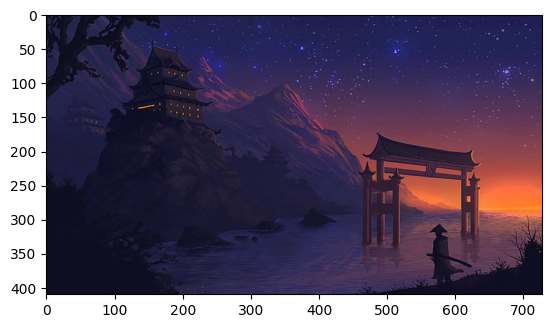

In [43]:
plt.imshow(image)

In [44]:
image.shape

(410, 728, 3)

In [45]:
x = image.reshape(-1,3)
x.shape

(298480, 3)

In [46]:
x

array([[20, 17, 44],
       [33, 31, 55],
       [21, 19, 40],
       ...,
       [15, 14, 32],
       [15, 14, 32],
       [15, 14, 32]], dtype=uint8)

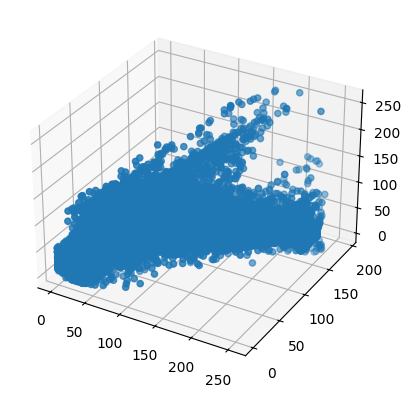

In [47]:
fig = plt.figure() # Create a figure (empty canvas)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:,0], x[:,1], x[:,2])

# K-Means model

In [48]:
from sklearn.cluster import KMeans
wcss = []
for i in range (1,11):
    kmeans = KMeans(n_init = 10, n_clusters = i )
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
print(wcss)

[902917817.0043597, 392741186.50067794, 221732676.64438012, 120933062.47942403, 92006827.60133757, 72943138.43925816, 59251043.75161376, 51477293.3240971, 46535814.03720036, 41709061.27506535]


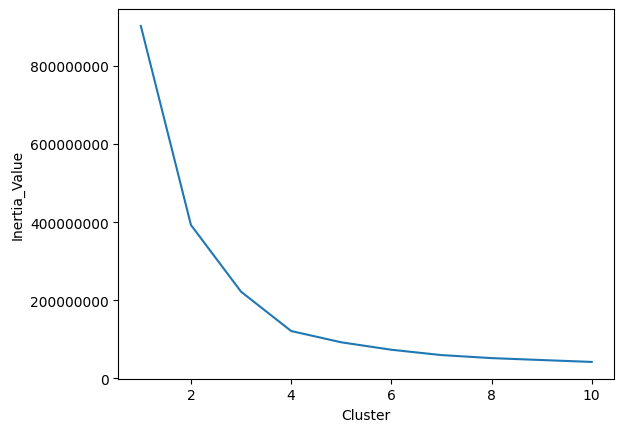

In [49]:
plt.plot(range(1,11),wcss)
plt.xlabel('Cluster')
plt.ylabel('Inertia_Value')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [50]:
# from sklearn.metrics import silhouette_score

# silhouette_scores = []

# for i in range(2, 11):   # start from 2 (important because we need at least 2 clusters )
#     kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
#     kmeans.fit(x)
#     labels = kmeans.labels_
#     silhouette_scores.append(silhouette_score(x, labels))

# print(silhouette_scores)


In [51]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(x)

KMeans(n_clusters=4)

In [52]:
kmeans.cluster_centers_

array([[ 45.23972561,  38.77231314,  83.25012168],
       [105.20092554,  61.38838873,  85.33708456],
       [212.35700152, 101.9891172 ,  68.58812785],
       [ 23.46618317,  20.55938405,  43.85659593]])

In [53]:
from PIL import Image, ImageDraw
import numpy as np

def create_color_palette(dominant_colors, palette_size=(300, 50)):
    # Create an image to display the colors
    palette = Image.new("RGB", palette_size)
    draw = ImageDraw.Draw(palette)

    # Calculate the width of each color swatch
    swatch_width = palette_size[0] // len(dominant_colors)

    # Draw each color as a rectangle on the palette
    for i, color in enumerate(dominant_colors):
        draw.rectangle([i * swatch_width, 0, (i + 1) * swatch_width, palette_size[1]], fill=tuple(color))

    return palette

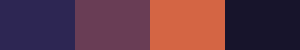

In [54]:
create_color_palette(kmeans.cluster_centers_.astype(int))

In [55]:
import pickle

# Save the KMeans model
with open("model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

print("Model saved!")

Model saved!


In [58]:
import openai

client = openai.OpenAI(
    api_key="YOUR_KEY",
    base_url="https://api.deepseek.com"
)
print(client)